# TP8 : Overfitting et validation

Importez les bibliothèques suivantes.

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Le TP précédent portait sur la régression linéaire. Le présent TP réutilisant la classe `MyRidgeRegression`, voici une cellule la définissant.

In [3]:
class MyRidgeRegression:
    def __init__(self):
        self.weights = None
        self.data = None
        self.output = None

    def fit(self, data, output, lambda_param):
        I = np.eye(data.shape[1])
        self.weights = np.linalg.inv(data.T @ data + lambda_param * I) @ data.T @ output
        self.data = data
        self.output = output

    def predict(self, data):
        return data @ self.weights

    def mse(self):
        predictions = self.predict(self.data)
        return np.mean((self.output - predictions)**2)

    def r2(self):
        predictions = self.predict(self.data)
        ss_res = np.sum((self.output - predictions)**2)
        ss_tot = np.sum((self.output - np.mean(self.output))**2)
        return 1 - (ss_res / ss_tot)

print("Classe MyRidgeRegression chargée.")

Classe MyRidgeRegression chargée.


Importez les jeux de données.

In [4]:
## from google.colab import files
## data_to_load = files.upload()
## import io
## df_prices = pd.read_csv(io.BytesIO(data_to_load['prices.csv']))

df_pixels = pd.read_csv("pixels.csv")
X = df_pixels.to_numpy(dtype="float32")
df_prices = pd.read_csv("prix.csv")
y = df_prices.values

print(f"Forme de X : {X.shape}")
print(f"Nombre de prix : {len(y)}")

Forme de X : (2535, 784)
Nombre de prix : 2535


---

## Introduction : du jeu d'entraînement au jeu de test

Dans le TP précédent, nous avons entraîné et évalué nos modèles sur le même jeu de données. Cette approche pose un problème fondamental : un modèle peut très bien mémoriser les données d'entraînement (obtenir un faible MSE sur ces données) sans pour autant avoir appris à généraliser à de nouvelles données.

Ce phénomène s'appelle le surapprentissage (overfitting). Pour l'évaluer, il faut séparer nos données en un jeu d'entraînement (pour ajuster les poids du modèle) et un jeu de test (pour évaluer sa capacité de généralisation).

L'objectif de ce TP est de comprendre l'overfitting et d'apprendre à utiliser la validation croisée pour sélectionner les hyperparamètres de manière rigoureuse.

### Reproductibilité et graines aléatoires (seeds)

Le découpage train/test est aléatoire. Pour garantir la reproductibilité des résultats (obtenir les mêmes découpages à chaque exécution), on utilise une graine aléatoire (seed). La fonction `np.random.seed(valeur)` initialise le générateur de nombres aléatoires de NumPy avec une valeur fixe. Deux exécutions avec le même seed produiront exactement les mêmes nombres aléatoires, donc le même découpage.

Dans ce TP, nous explorerons également l'impact du choix du seed sur la stabilité des modèles. Un modèle robuste devrait donner des performances similaires quel que soit le découpage aléatoire des données.

## Exercice 1

1. Créez une fonction `train_test_split(data, labels, train_ratio=0.8, seed=42)` qui prend en entrée `data` et `labels`, mélange les indices avec `np.random.permutation` (**[documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html)**) après avoir fixé le seed avec `np.random.seed(seed)`, découpe selon `train_ratio`, et retourne `data_train`, `data_test`, `labels_train`, `labels_test`. Testez cette fonction en affichant les dimensions des ensembles retournés.

In [15]:
## Écrivez votre code ici.
def train_test_split(data,labels,train_ration=0.8,seed=42):
    np.random.seed(seed)
    indices=np.random.permutation(len(data))
    train_size=int(len(data)*train_ration)
    train_indices=indices[:train_size]
    test_indices=indices[train_size:]
    return data[train_indices],labels[train_indices],data[test_indices],labels[test_indices]

2. Pour étudier la stabilité du modèle, testez plusieurs découpages différents en variant le seed. Pour chacun des seeds suivants : `42`, `123`, `456`, `789`, `101`, `202`, `303`, `404`, `505`, `606`, créez un découpage train/test, entraînez un modèle Ridge avec `lambda = 1.0`, et stockez le MSE test. Affichez ensuite la moyenne et l'écart-type des MSE test obtenus. Refaites la même chose avec `lambda = 1000`. Affichez les résultats sous forme de tableau comparatif.

In [16]:
## Écrivez votre code ici.
seed_values=[42,123,456,789,101,202,303,404,505,606]
Mse_values_lambda_1=[]
Mse_values_lambda_1k=[]
for seed in seed_values:
    X_train,y_train,X_test,y_test=train_test_split(X,y,train_ration=0.8,seed=seed)
    
    model1=MyRidgeRegression()
    model2=MyRidgeRegression()
    
    model1.fit(X_train,y_train,lambda_param=1.0)
    model2.fit(X_train,y_train,lambda_param=1000.0)
    
    pred1 = model1.predict(X_test)
    pred2 = model2.predict(X_test)
    
    mse_test_1 = np.mean((y_test - pred1)**2)
    mse_test_1k = np.mean((y_test - pred2)**2)
    
    Mse_values_lambda_1.append(mse_test_1)
    Mse_values_lambda_1k.append(mse_test_1k)
    

print(f"la moyenne des MSE avec lambda=1 : {np.mean(Mse_values_lambda_1)} et l'écart type : {np.std(Mse_values_lambda_1)}")
print(f"la moyenne des MSE avec lambda=1000 : {np.mean(Mse_values_lambda_1k)} et l'écart type : {np.std(Mse_values_lambda_1k)}")




la moyenne des MSE avec lambda=1 : 45504.425020687384 et l'écart type : 34659.16903533724
la moyenne des MSE avec lambda=1000 : 834.8466877526174 et l'écart type : 175.53378437775726


3. Que constatez-vous sur la variabilité des résultats entre les deux valeurs de $\lambda$ ? Quel est le rôle de la régularisation par rapport à la stabilité du modèle ?

1)- On remarque que λ avec le plus grande valeure prédit mieux les données.
2)- écarts-types : Avec λ=1, les performances varient énormément selon le découpage le modèle est instable. Avec λ=1000, les performances restent similaires quel que soit le seed,le modèle est donc stable

3)-La régularisation (grand λ) contraint les poids du modèle à rester petits. Cela empêche le modèle de trop s'adapter aux détails spécifiques des données d'entraînement

4. Les courbes d'apprentissage permettent de visualiser comment les performances évoluent en fonction de la taille du jeu d'entraînement. Pour différentes tailles de jeu d'entraînement (30%, 40%, 50%, 60%, 70%, 80%, 90%, 100% des données d'entraînement), entraînez un modèle Ridge avec `lambda = 1000` et calculez le MSE train et le MSE test. Tracez deux courbes sur le même graphique : MSE train en fonction de la taille et MSE test en fonction de la taille. Testez plusieurs seeds.

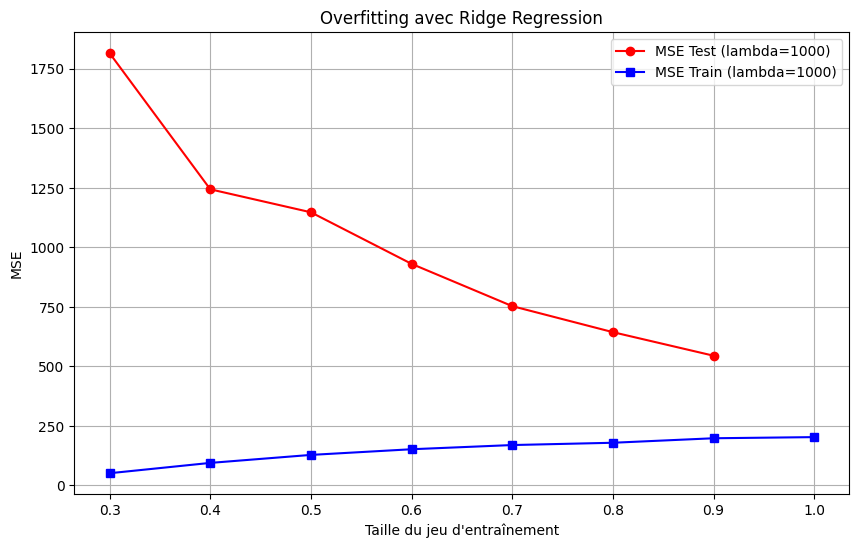

In [17]:
## Écrivez votre code ici.
taille_jeu=[0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
mse_test_1000=[]
mse_train_1000=[]

for taille in taille_jeu:
    X_train,y_train,X_test,y_test=train_test_split(X,y,train_ration=taille,seed=42)
    
    model=MyRidgeRegression()
    model.fit(X_train,y_train,lambda_param=1000.0)
    
    pred_test = model.predict(X_test)
    pred_train = model.predict(X_train)
    
    mse_test = np.mean((y_test - pred_test)**2)
    mse_train = np.mean((y_train - pred_train)**2)
    
    mse_test_1000.append(mse_test)
    mse_train_1000.append(mse_train)
plt.figure(figsize=(10, 6))
plt.plot(taille_jeu, mse_test_1000, marker='o', label='MSE Test (lambda=1000)', color='red')
plt.plot(taille_jeu, mse_train_1000, marker='s', label='MSE Train (lambda=1000)', color='blue')
plt.xlabel('Taille du jeu d\'entraînement')
plt.ylabel('MSE')
plt.title('Overfitting avec Ridge Regression')
plt.legend()
plt.grid(True)
plt.show()

5. Que constatez-vous sur l'évolution du MSE train et du MSE test en fonction de la taille du jeu d'entraînement ? Comment l'écart entre les deux courbes évolue-t-il ?

Mse_test: commence très haut avec peu de données,et commence après àdiminuer fortement
Mse_train: commence bas avec peu de données, et augmente légèrement quand la taille de jeu augmente

l'écart: on remarque que l'écart qui était énorme au début avec peu de données  se réduit progressivement mais reste quand meme important

## Exercice 2

Le paramètre de régularisation $\lambda$ contrôle la complexité du modèle. Un $\lambda$ trop petit peut conduire à l'overfitting (le modèle mémorise le bruit des données d'entraînement), tandis qu'un $\lambda$ trop grand peut conduire à l'underfitting (le modèle est trop simple pour capturer les patterns).

1. Pour différentes valeurs de `lambda` (`0.1`, `1`, `10`, `100`, `1000`, `10000`, `100000`, `1000000`, `10000000`, `100000000`, `1000000000`), entraînez un modèle Ridge sur le jeu d'entraînement complet et calculez le MSE train et le MSE test. Tracez les deux courbes sur le même graphique (échelle logarithmique pour les deux axes). Note : nous travaillons avec 784 paramètres, ce qui explique que les valeurs optimales de $\lambda$ sont très grandes.

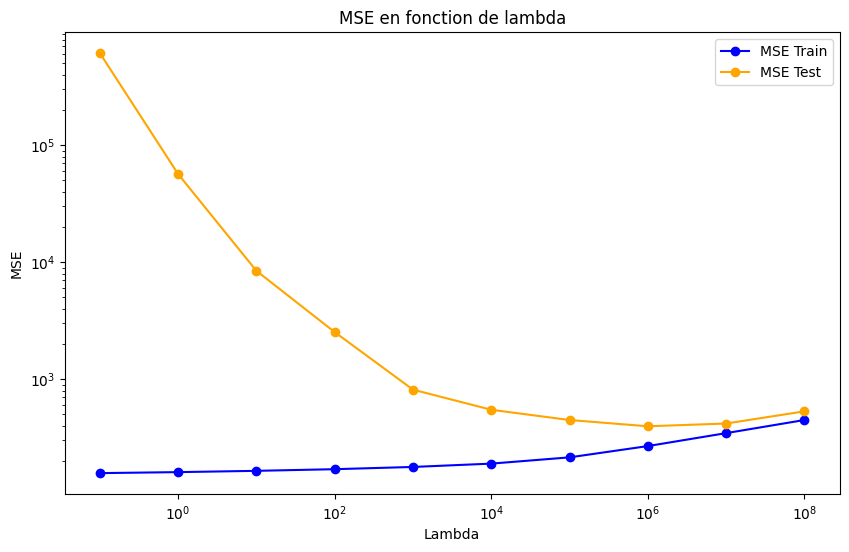

In [7]:
lambda_values = [0.1,1,10,100,1000,10000,100000,1000000,10000000,100000000]
model=MyRidgeRegression()
Mse_test=[]
Mse_train=[]

for p in lambda_values:
    model.fit(X_train,y_train,lambda_param=p)
    
    pred_train=model.predict(X_train)
    pred_test=model.predict(X_test)
    
    mse_train=np.mean((y_train - pred_train)**2)
    mse_test=np.mean((y_test - pred_test)**2)
    
    Mse_train.append(mse_train)
    Mse_test.append(mse_test)
    
plt.figure(figsize=(10,6))
plt.plot(lambda_values, Mse_train, label='MSE Train', marker='o',color='blue')
plt.plot(lambda_values, Mse_test, label='MSE Test', marker='o',color='orange')
plt.title('MSE en fonction de lambda')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.legend()



2. Identifiez la zone d'overfitting (petit $\lambda$) et la zone d'underfitting (grand $\lambda$). Quelle valeur de $\lambda$ minimise le MSE test ? Est-ce la même qui minimise le MSE train ?

1)- à gauche(gamma petit): le mse test est très haut contrairement au mse train qui est tres bas , donc le modèle mémorise les données et généralise mal (overffitting)

2)- à droite(gamma grand):À droite, les deux courbes se rejoignent et remontent. Le modèle est contraint et n'apprend plus grand.c'est l'underfitting.

3)-le mse test est minimal auteur de  100000 et 1 000 000
4)- c'est pas la meme valeur qui minimise les deux valeurs, car le mse train est minimal avec des valeures petites de gamma

## Exercice 3

L'exercice précédent pose un problème : nous avons utilisé le jeu de test pour choisir le meilleur $\lambda$. Or, le jeu de test doit rester "vierge" et ne servir qu'à l'évaluation finale du modèle. Si on l'utilise pour sélectionner les hyperparamètres, on risque de surajuster sur ce jeu de test.

La solution est la validation croisée (cross-validation). L'idée est de découper le jeu d'entraînement en k sous-ensembles (folds), d'entraîner k modèles (chacun sur k-1 folds et testé sur le fold restant), puis de moyenner les performances.

1. Construisez une fonction `cross_validate(data, labels, k_folds, lambda_param)` qui découpe `data` et `labels` en `k_folds` parties égales, entraîne `k` modèles Ridge avec le paramètre `lambda_param` donné, et retourne la moyenne des MSE obtenus sur chaque fold de validation. Utilisez cette fonction pour tester `k_folds = 5` avec `lambda_param = 10000`.

In [8]:
def cross_validation(data,labels,k_folds,lambda_param):
    mse_values=[]
    size=len(data)//k_folds
    
    for i in range(k_folds):
        start=i*size
        end=(i+1)*size if i!=k_folds-1 else len(data)
        
        X_val=data[start:end]
        y_val=labels[start:end]
        
        # [[val] [train][train]...]
        #[[train][val] [train]...]
        X_train=np.concatenate((data[:start],data[end:]),axis=0)
        y_train=np.concatenate((labels[:start],labels[end:]),axis=0)
        
        model=MyRidgeRegression()
        model.fit(X_train,y_train,lambda_param)
        
        pred=model.predict(X_val)
        mse=np.mean((y_val - pred)**2)
        mse_values.append(mse)
        
    return np.mean(mse_values)
        
        
cross_validation(X,y,k_folds=5,lambda_param=10000.0)

np.float64(630.7418528946368)

2. Utilisez la validation croisée pour sélectionner le meilleur $\lambda$ parmi les valeurs testées précédemment. Pour chaque valeur, calculez le MSE cross-validation. Affichez les résultats et identifiez le meilleur $\lambda$.

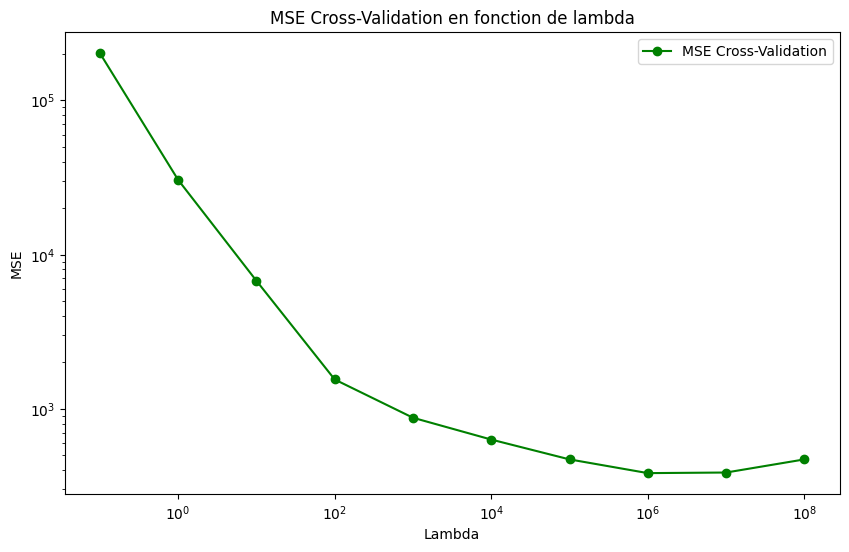

In [ ]:
## Écrivez votre code ici.
mse=[]
for p in lambda_values:
    mse.append(cross_validation(X,y,k_folds=5,lambda_param=p))
plt.figure(figsize=(10,6))
plt.plot(lambda_values, mse, label='MSE Cross-Validation', marker='o',color='green')
plt.title('MSE Cross-Validation en fonction de lambda')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.legend()
plt.show()

## le meilleur lambda est celui qui minimise le MSE de la validation croisée, dans ce cas c'est  10puissance 6

3. Comparez le $\lambda$ sélectionné par validation croisée avec celui qui minimisait le MSE test dans l'exercice 2. Sont-ils identiques ? Même si les performances finales sont similaires, expliquez pourquoi la méthode par validation croisée est méthodologiquement supérieure.

les deux mse sont proches certes mais pas identiques.
l'avantage de la cross_validation est que gamma est séléctionné seulement sur le train set et que le jeu de test est utlisé pour l'évolution finale contrairement à l'exo 2.

## Exercice 4 (Bonus)

1. Que se passe-t-il quand $\lambda$ devient très grand (tend vers l'infini) dans la formule Ridge : $\mathbf{w} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$ ? Vers quelle valeur tendent les poids ?

pour des gamma tres grands , l'expression  (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} est dominé par gamma * I  .
 w=X transpose * y/ GAMMA  ->0

2. Entraînez deux modèles Ridge sur le jeu d'entraînement : un avec $\lambda = 1$ et un avec $\lambda = 10^{15}$ (régularisation extrême). Pour chaque modèle, calculez le MSE test, affichez les 10 premières prédictions avec les vraies valeurs correspondantes, ainsi que le minimum et le maximum des prédictions. Que constatez-vous sur le comportement des deux modèles ?

In [10]:
## Écrivez votre code ici.
model1=MyRidgeRegression()
model2=MyRidgeRegression()

model1.fit(X_train,y_train,lambda_param=1.0)
model2.fit(X_train,y_train,lambda_param=10**15)

pred1 = model1.predict(X_test).flatten()
pred2 = model2.predict(X_test).flatten()

mse_test_1 = np.mean((y_test - pred1)**2)
mse_test_2 = np.mean((y_test - pred2)**2)

print(f"MSE avec lambda=1 : {mse_test_1}")
print(f"MSE avec lambda=10**15 : {mse_test_2}")

print("\n--- Lambda = 1 ---")
print(f"{'Prédit':>12}  {'Réel':>12}")
for i in range(10):
    print(f"{pred1[i]:>12.2f}  {y_test.flatten()[i]:>12.2f}")

print("\n--- Lambda = 1e15 ---")
print(f"{'Prédit':>12}  {'Réel':>12}")
for i in range(10):
    print(f"{pred2[i]:>12.2f}  {y_test.flatten()[i]:>12.2f}")

print(f"\nLambda=1    → min: {pred1.min():.2f}, max: {pred1.max():.2f}")
print(f"Lambda=1e15 → min: {pred2.min():.2f}, max: {pred2.max():.2f}")

MSE avec lambda=1 : 58799.71827301062
MSE avec lambda=10**15 : 9035.114871938698

--- Lambda = 1 ---
      Prédit          Réel
       57.61         43.90
       38.34         51.46
       57.29         70.53
      185.76        134.48
       44.31         64.95
       71.89         59.59
      123.83        136.56
      116.21        126.85
       78.96        148.85
      139.79        133.33

--- Lambda = 1e15 ---
      Prédit          Réel
        0.00         43.90
        0.00         51.46
        0.00         70.53
        0.00        134.48
        0.00         64.95
        0.00         59.59
        0.00        136.56
        0.00        126.85
        0.00        148.85
        0.00        133.33

Lambda=1    → min: -3043.40, max: 1792.14
Lambda=1e15 → min: 0.00, max: 0.00


le comportement des deux modèles :
1)- gamma=10**15 : comme attendu, on a eu des zeros, car les poids tendent vers 0 (comme éxpliqué à la question précédente)
2)- gamma =1 : le modèle a appris des patterns, car les prédictions suivent globalement les valeurs réelles,maisn avec une grande variance (signe d'overfitting)

3. D'après vos observations, le MSE seul est-il une métrique suffisante pour détecter ce type de problème ? Proposez une approche ou une métrique complémentaire qui permettrait d'identifier qu'un modèle ne fait rien d'utile. Implémentez cette métrique pour les deux modèles ($\lambda = 1$ et $\lambda = 10^{15}$) et comparez avec un modèle Ridge ayant un $\lambda$ optimal (celui trouvé dans l'exercice 3).

In [13]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

r2_lambda_1 = r2_score(y_test.flatten(), pred1)
r2_lambda_2=r2_score(y_test.flatten(), pred2)


model_opt=MyRidgeRegression()
model_opt.fit(X_train,y_train,lambda_param=10**6)
pred_opt=model_opt.predict(X_test).flatten()
mse_opt=np.mean((y_test - pred_opt)**2)
r2_lambda_opt = r2_score(y_test.flatten(), pred_opt)

print(f"{'Modèle':<15} {'MSE':>12} {'R²':>10}")
print("-" * 40)
print(f"{'λ=1':<15} {mse_test_1:>12.2f} {r2_lambda_1:>10.4f}")
print(f"{'λ=1e15':<15} {mse_test_2:>12.2f} {r2_lambda_2:>10.4f}")
print(f"{'λ=1e6 (opt)':<15} {mse_opt:>12.2f} {r2_lambda_opt:>10.4f}")


Modèle                   MSE         R²
----------------------------------------
λ=1                 58799.72   -47.0497
λ=1e15               9035.11    -6.6619
λ=1e6 (opt)          2519.34     0.6645


l'autre métrique (qu'on a déja vu lors du tp précédent est le R2_score) .